In [1]:
# Importing packages and libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Reading dataset
df = pd.read_csv(
    r"C:\Users\adero\Downloads\New Projects\AnalystLab Africa\Week 1-2\Netflix Dataset\netflix_titles.csv"
)

In [3]:
# Displayed the first ten rows
df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [4]:
# Checked the shape of the dataset
df.shape

(8807, 12)

In [5]:
# Displayed the data types
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [6]:
# Converting the data type of 'date_added' to date time
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [7]:
#Confirmed changes were made
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [8]:
# Split the duration column into duration value and duration unit
df[["duration_value", "duration_unit"]] = df["duration"].str.split(" ", n=1, expand=True)

In [9]:
# Converted Duration Value to Numeric
df["duration_value"] = pd.to_numeric(df["duration_value"])

# Standardized the Duration Unit Column
df["duration_unit"] = df["duration_unit"].replace({
    "Season": "Seasons"
})

# Checked the results
df[["duration", "duration_value", "duration_unit"]].head(10)

,duration,duration_value,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Seasons
3,1 Season,1.0,Seasons
4,2 Seasons,2.0,Seasons
5,1 Season,1.0,Seasons
6,91 min,91.0,min
7,125 min,125.0,min
8,9 Seasons,9.0,Seasons
9,104 min,104.0,min


In [10]:
# Checked the total number of missing values in each column of the dataset
df.isnull().sum()

show_id              0
type                 0
title                0
director          2634
cast               825
country            831
date_added          98
release_year         0
rating               4
duration             3
listed_in            0
description          0
duration_value       3
duration_unit        3
dtype: int64

In [11]:
# Handling missing entries

# Fill missing director
df["director"] = df["director"].fillna("Unknown")

# Fill missing cast
df["cast"] = df["cast"].fillna("Not Available")

# Fill missing country
df["country"] = df["country"].fillna("Unknown")

# Fill missing date added
df["date_added"] = df["date_added"].fillna("Not Specified")

# Fill missing ratings
df["rating"] = df["rating"].fillna("Not Rated")

# Convert duration value to numeric
df["duration_value"] = pd.to_numeric(df["duration_value"], errors="coerce")

# Fill missing duration units
df["duration_unit"] = df["duration_unit"].fillna("Unknown")

In [12]:
# Confirmed all missing rows have been sorted
df[["director", "cast", "country", "date_added", "rating", "duration_value", "duration_unit"]].isnull().sum()

director          0
cast              0
country           0
date_added        0
rating            0
duration_value    3
duration_unit     0
dtype: int64

In [13]:
# Inspected duration value
df[df["duration_value"].isnull()][
    ["title", "type", "duration"]
]

,title,type,duration
5541,Louis C.K. 2017,Movie,NaN
5794,Louis C.K.: Hilarious,Movie,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,NaN


In [14]:
# Displaying duplicate values
df.duplicated().sum()

np.int64(0)

In [15]:
# Confimed that no entry in Show ID had a duplicate
df["show_id"].duplicated().sum()

np.int64(0)

In [16]:
# Removed extra spaces
text_columns = ["type", "title", "director", "cast", "country", "rating", "listed_in"]

for col in text_columns:
    df[col] = df[col].str.strip()

In [17]:
#Checking unique values in type
df["type"].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [18]:
#Checking unique values in ratings
df["rating"].unique()

<StringArray>
[    'PG-13',     'TV-MA',        'PG',     'TV-14',     'TV-PG',      'TV-Y',
     'TV-Y7',         'R',      'TV-G',         'G',     'NC-17',    '74 min',
    '84 min',    '66 min',        'NR', 'Not Rated',  'TV-Y7-FV',        'UR']
Length: 18, dtype: str

In [19]:
df["rating"] = df["rating"].replace({
    "NR": "Not Rated"
})

In [20]:
# Displaying distribution of release year
df["release_year"].describe()

count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

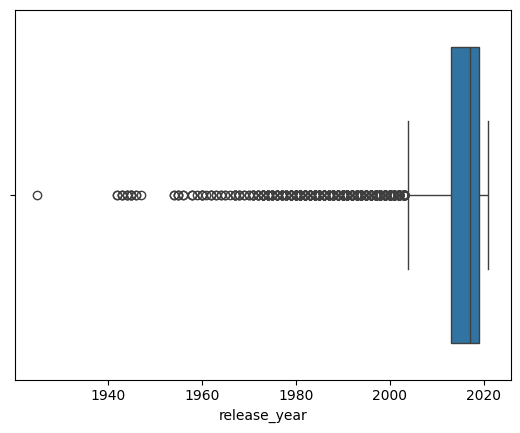

In [21]:
# Creating a boxplot to visualize outliers in release year
sns.boxplot(x=df["release_year"])
plt.show()

In [22]:
# Filtered the dataset to include only movies with duration measured in minutes
movies = df[df["duration_unit"] == "min"]

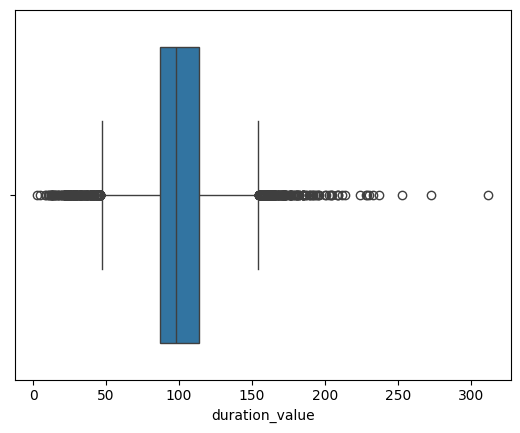

In [23]:
# Creates a boxplot to visualize the distribution and detect outliers in movie durations (in minutes)
sns.boxplot(x=movies["duration_value"])
plt.show()

In [24]:
# Filtered the dataset to include only shows with duration measured in seasons
shows = df[df["duration_unit"] == "Seasons"]

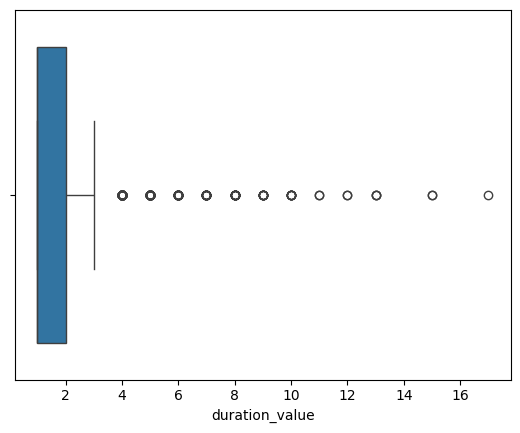

In [25]:
# Creates a boxplot to visualize the distribution and detect outliers in the number of seasons
sns.boxplot(x=shows["duration_value"])
plt.show()

In [26]:
df.describe()

,release_year,duration_value
count,8807.000000,8804.000000
mean,2014.180198,69.846888
std,8.819312,50.814828
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


In [27]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

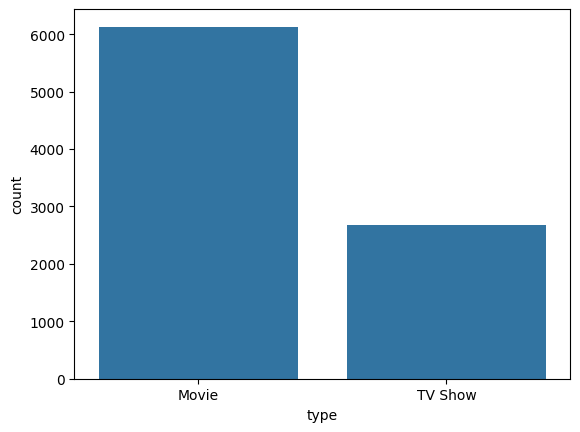

In [28]:
sns.countplot(x=df["type"])
plt.savefig(r"C:\Users\adero\Downloads\New Projects\Movies_vs_Tv_Shows.png", dpi=300, bbox_inches="tight")
plt.show()

In [29]:
# Displayed the frequency distribution of different content ratings in the dataset
df["rating"].value_counts()

rating
TV-MA        3207
TV-14        2160
TV-PG         863
R             799
PG-13         490
TV-Y7         334
TV-Y          307
PG            287
TV-G          220
Not Rated      84
G              41
TV-Y7-FV        6
NC-17           3
UR              3
74 min          1
84 min          1
66 min          1
Name: count, dtype: int64

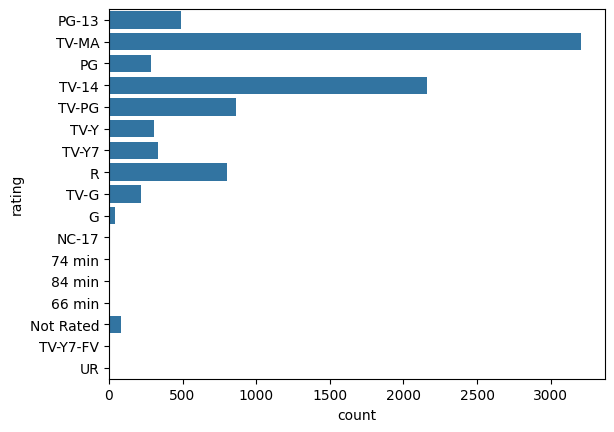

In [30]:
# Visualizes the distribution of content ratings using a horizontal bar chart
sns.countplot(y=df["rating"])
plt.savefig(r"C:\Users\adero\Downloads\New Projects\Netflix_content_ratings_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
# Displayed the top 10 countries producing the most Netflix content
df["country"].value_counts().head(10)

country
United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

In [32]:
 # Showed the number of titles released per year in chronological order
df["release_year"].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

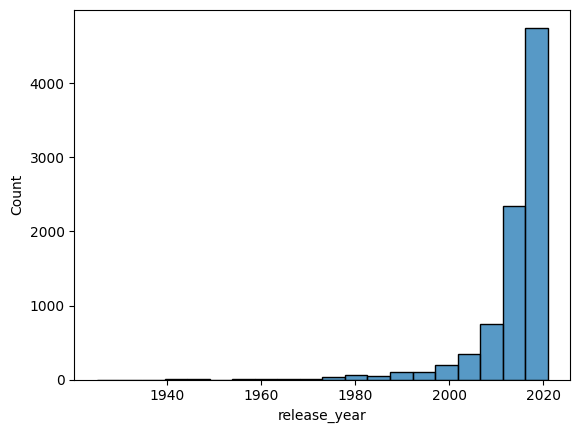

In [33]:
# Visualized the distribution of content release years
sns.histplot(df["release_year"], bins=20)
plt.show()

In [34]:
# Filters dataset to include only movies with duration measured in minutes
movies = df[df["duration_unit"] == "min"]

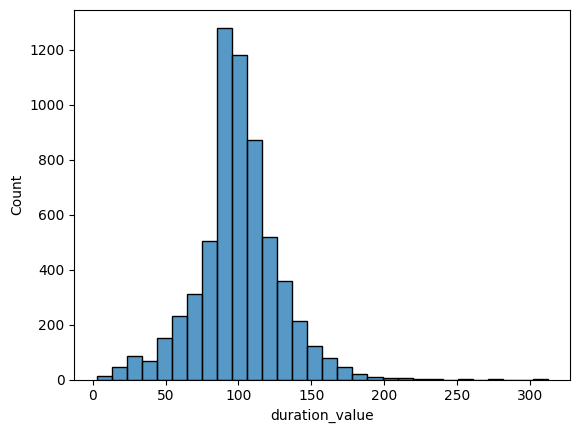

In [35]:
# Displayed the distribution of movie durations (in minutes)
sns.histplot(movies["duration_value"], bins=30)
plt.savefig(r"C:\Users\adero\Downloads\New Projects\distribution_of_movie_durations.png", dpi=300, bbox_inches="tight")
plt.show()

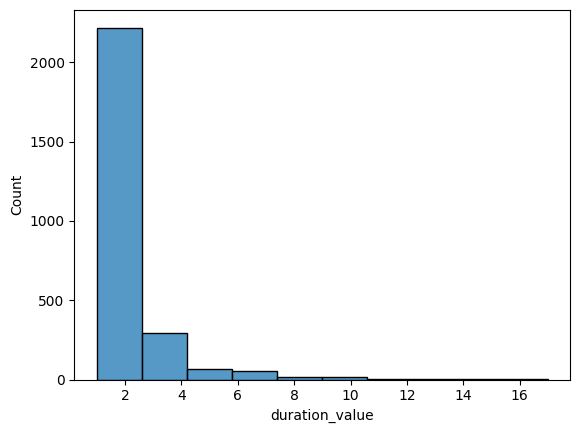

In [36]:
# Filtered the dataset to include only TV shows with duration measured in seasons
shows = df[df["duration_unit"] == "Seasons"]

# Displayed the distribution of the number of seasons per TV show
sns.histplot(shows["duration_value"], bins=10)
plt.show()

In [37]:
# Converted the date_added column from string format to datetime format
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [38]:
 # Extracted the year when each title was added to Netflix
df["year_added"] = df["date_added"].dt.year

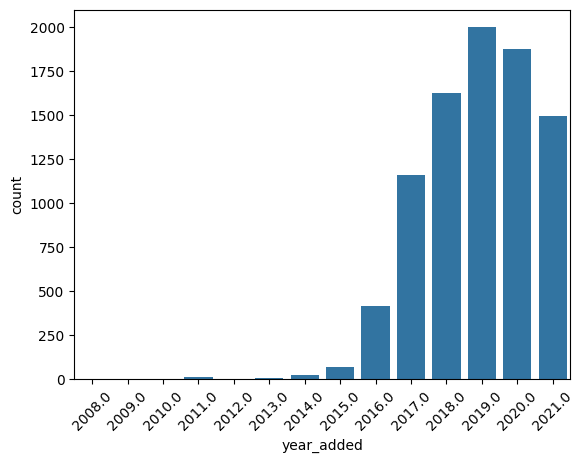

In [39]:
# Displayed the number of titles added to Netflix per year
sns.countplot(x=df["year_added"])

# Rotated the x-axis labels for better readability
plt.xticks(rotation=45)
plt.show()